In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

In [3]:
movies = pd.read_csv('../data/wiki_movie_plots_deduped.csv')

top_5_genres = ['drama', 'comedy', 'horror', 'action', 'thriller']
df = movies[movies['Genre'].isin(top_5_genres)].copy()

print("Dataset shape:", df.shape)
print("\nGenre Distribution")
print(df['Genre'].value_counts())

Dataset shape: (13574, 8)

Genre Distribution
Genre
drama       5964
comedy      4379
horror      1167
action      1098
thriller     966
Name: count, dtype: int64


In [4]:
# Fixing class imbalance (About 44% of genres are drama)
# smallest sample size for top 5 is 966 for thriller
# Take an equal sample size of 966 for each of the 5 genres 
min_count = df['Genre'].value_counts().min()

df_balanced = pd.concat([
    df[df['Genre'] == genre].sample(min_count, random_state=42)
    for genre in top_5_genres
]).reset_index(drop=True)

print("Balanced genre distribution:")
print(df_balanced['Genre'].value_counts())
print("\nTotal samples:", len(df_balanced))


Balanced genre distribution:
Genre
drama       966
comedy      966
horror      966
action      966
thriller    966
Name: count, dtype: int64

Total samples: 4830


In [5]:
# Train/Test Split
X = df_balanced['Plot']
y = df_balanced['Genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4347
Testing samples: 483


In [6]:
# Building & Training the model!
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range = (1,2),
    stop_words = 'english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

TF-IDF matrix shape (train): (4347, 5000)
TF-IDF matrix shape (test): (483, 5000)


In [7]:
# Training Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 62.32%

Classification Report:
              precision    recall  f1-score   support

      action       0.68      0.77      0.72        97
      comedy       0.61      0.62      0.62        96
       drama       0.54      0.58      0.56        97
      horror       0.74      0.70      0.72        97
    thriller       0.53      0.44      0.48        96

    accuracy                           0.62       483
   macro avg       0.62      0.62      0.62       483
weighted avg       0.62      0.62      0.62       483



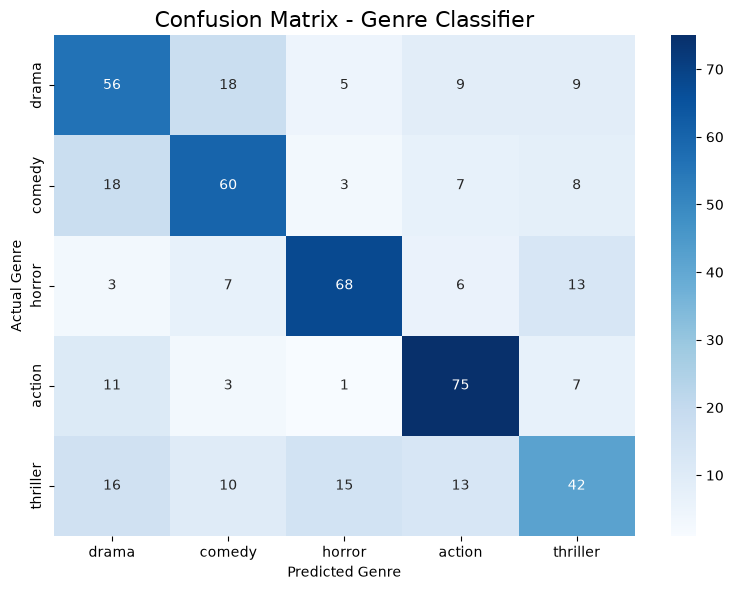

In [8]:
# Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=top_5_genres)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_5_genres,
            yticklabels=top_5_genres)
ax.set_title('Confusion Matrix - Genre Classifier', fontsize=16)
ax.set_xlabel('Predicted Genre')
ax.set_ylabel('Actual Genre')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150)
plt.show()

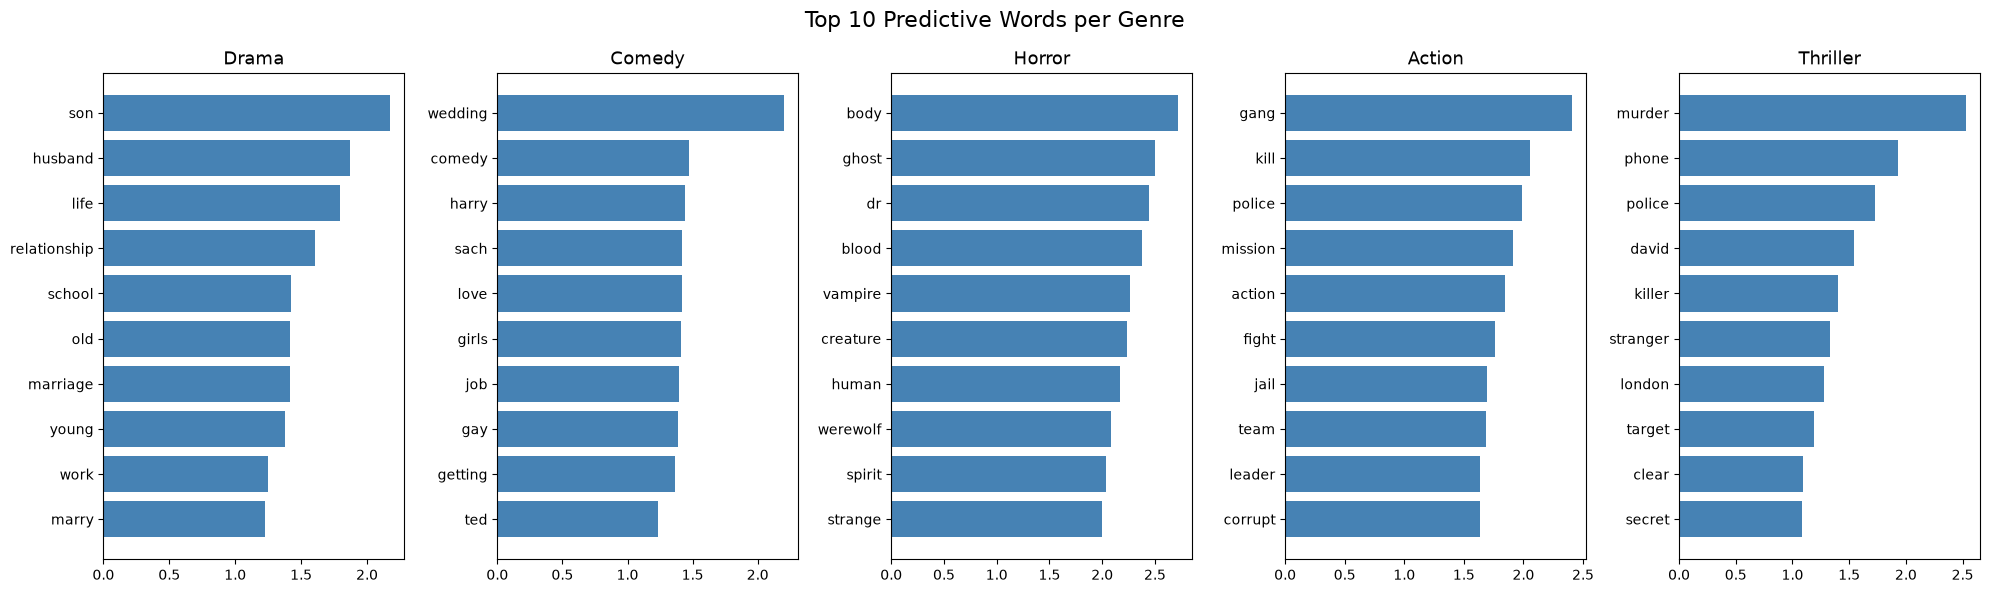

In [9]:
# 10 Most Predictive Words per Genre
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, genre in enumerate(top_5_genres):
    genre_idx = list(model.classes_).index(genre)
    top_indices = model.coef_[genre_idx].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [model.coef_[genre_idx][j] for j in top_indices]
    
    axes[i].barh(top_words, top_scores, color='steelblue')
    axes[i].set_title(f'{genre.capitalize()}', fontsize=13)
    axes[i].invert_yaxis()

plt.suptitle('Top 10 Predictive Words per Genre', fontsize=16)
plt.tight_layout()
plt.savefig('../images/top_words_per_genre.png', dpi=150)
plt.show()